# PCDA | Winter 2026 
### Final Project - Motor Vehicle Collisions Crashes
### Author: Bipika Sapkota & Pooja Mengaji 


### Data cleaning 

Importing the dataset into the Jupyter Notebook using pandas.

In [49]:
import pandas as pd

df = pd.read_csv("data/Motor_Vehicle_Collisions_Crashes.csv")
df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230.0,40.62179,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN


Examining data structure by checking the number of rows and columns, column names, and data types. This helps us understand the dataset and identify any missing values or inconsistencies that needs to be addressed.

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 29 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   CRASH DATE                     1048575 non-null  str    
 1   CRASH TIME                     1048575 non-null  str    
 2   BOROUGH                        680750 non-null   str    
 3   ZIP CODE                       680576 non-null   float64
 4   LATITUDE                       970365 non-null   float64
 5   LONGITUDE                      970365 non-null   float64
 6   LOCATION                       970365 non-null   str    
 7   ON STREET NAME                 782651 non-null   str    
 8   CROSS STREET NAME              504057 non-null   str    
 9   OFF STREET NAME                264811 non-null   str    
 10  NUMBER OF PERSONS INJURED      1048562 non-null  float64
 11  NUMBER OF PERSONS KILLED       1048555 non-null  float64
 12  NUMBER OF PEDESTRIANS INJ

Since there are so many variables that we will not be using for this project, we are selecting only the variables that are relevant to our analysis, as it reduces the complexity. 

In [51]:
columns_to_keep = [
    "CRASH DATE",
    "CRASH TIME",
    "BOROUGH",
    "ZIP CODE",
    "LATITUDE",
    "LONGITUDE",
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
    "CONTRIBUTING FACTOR VEHICLE 1",
    "VEHICLE TYPE CODE 1",
    "COLLISION_ID"
]

df = df[columns_to_keep]

In [52]:
df.isnull().sum()

CRASH DATE                            0
CRASH TIME                            0
BOROUGH                          367825
ZIP CODE                         367999
LATITUDE                          78210
LONGITUDE                         78210
NUMBER OF PERSONS INJURED            13
NUMBER OF PERSONS KILLED             20
NUMBER OF PEDESTRIANS INJURED         0
NUMBER OF CYCLIST INJURED             0
NUMBER OF MOTORIST INJURED            0
CONTRIBUTING FACTOR VEHICLE 1      4476
VEHICLE TYPE CODE 1                9733
COLLISION_ID                          0
dtype: int64

Handeling the missing vlaues 

In [53]:
df["BOROUGH"] = df["BOROUGH"].fillna("Unknown")

injury_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED"
]

df[injury_cols] = df[injury_cols].fillna(0)

df["CONTRIBUTING FACTOR VEHICLE 1"] = df["CONTRIBUTING FACTOR VEHICLE 1"].fillna("Unspecified")
df["VEHICLE TYPE CODE 1"] = df["VEHICLE TYPE CODE 1"].fillna("Unknown")

We notice that a large portion of the dataset has missing values for both borough and zip code, and these two fields are missing together in most cases. Since this represents a significant part of the data, we decide not to remove those rows in order to avoid losing a large amount of information. Instead, we replaced the missing borough values with "Unknown" so that these records can still be included in the analysis, especially for time-based patterns and injury-related insights. We keep the zip code values as missing since they are not essential for the main analysis.

Missing values in injury-related columns are replaced with 0, assuming no reported injuries. Missing values in contributing factors and vehicle type columns are replaced with "Unspecified" and "Unknown" respectively. This allows us to preserve as much data as possible without removing important records.

In [54]:
df["CRASH DATE"] = pd.to_datetime(df["CRASH DATE"])
df["CRASH TIME"] = pd.to_datetime(df["CRASH TIME"], format="%H:%M", errors="coerce")

In [55]:
df["HOUR"] = df["CRASH TIME"].dt.hour
df["YEAR"] = df["CRASH DATE"].dt.year
df["MONTH"] = df["CRASH DATE"].dt.month_name()
df["DAY"] = df["CRASH DATE"].dt.day
df["DAY_OF_WEEK"] = df["CRASH DATE"].dt.day_name()

In [56]:
df[["CRASH DATE", "CRASH TIME", "YEAR", "MONTH", "DAY", "DAY_OF_WEEK", "HOUR"]].head()

,CRASH DATE,CRASH TIME,YEAR,MONTH,DAY,DAY_OF_WEEK,HOUR
0,2021-09-11,1900-01-01 02:39:00,2021,September,11,Saturday,2
1,2022-03-26,1900-01-01 11:45:00,2022,March,26,Saturday,11
2,2023-11-01,1900-01-01 01:29:00,2023,November,1,Wednesday,1
3,2022-06-29,1900-01-01 06:55:00,2022,June,29,Wednesday,6
4,2022-09-21,1900-01-01 13:21:00,2022,September,21,Wednesday,13


In [57]:
df.isnull().sum()

CRASH DATE                            0
CRASH TIME                            0
BOROUGH                               0
ZIP CODE                         367999
LATITUDE                          78210
LONGITUDE                         78210
NUMBER OF PERSONS INJURED             0
NUMBER OF PERSONS KILLED              0
NUMBER OF PEDESTRIANS INJURED         0
NUMBER OF CYCLIST INJURED             0
NUMBER OF MOTORIST INJURED            0
CONTRIBUTING FACTOR VEHICLE 1         0
VEHICLE TYPE CODE 1                   0
COLLISION_ID                          0
HOUR                                  0
YEAR                                  0
MONTH                                 0
DAY                                   0
DAY_OF_WEEK                           0
dtype: int64

In [58]:
df = df.rename(columns={
    "CRASH DATE": "CRASH DATE", #"crash_date",
    "CRASH TIME": "CRASH TIME", #"crash_time",
    "BOROUGH": "BOROUGH",
    "ZIP CODE": "ZIP CODE", #"zip_code",
    "LATITUDE": "LATITUDE",
    "LONGITUDE": "LONGITUDE",
    "NUMBER OF PERSONS INJURED":  "NUMBER OF PERSONS INJURED", # "persons_injured",
    "NUMBER OF PERSONS KILLED": "NUMBER OF PERSONS KILLED", #"persons_killed",
    "NUMBER OF PEDESTRIANS INJURED": "NUMBER OF PEDESTRIANS INJURED", #"pedestrians_injured",
    "NUMBER OF CYCLIST INJURED": "NUMBER OF CYCLIST INJURED", #"cyclists_injured",
    "NUMBER OF MOTORIST INJURED": "NUMBER OF MOTORIST INJURED", #"motorists_injured",
     "CONTRIBUTING FACTOR VEHICLE 1": "CONTRIBUTING FACTOR",
     "VEHICLE TYPE CODE 1": "VEHICLE TYPE",
    "COLLISION_ID": "COLLISION_ID"
 })

In [59]:
df.to_csv("data/Cleaned_Motor_Vehicle_Collisions_Crashes.csv", index=False)

### PERFORMING EDA AND PLOTTING

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

## Box plot - Distribution by Factor

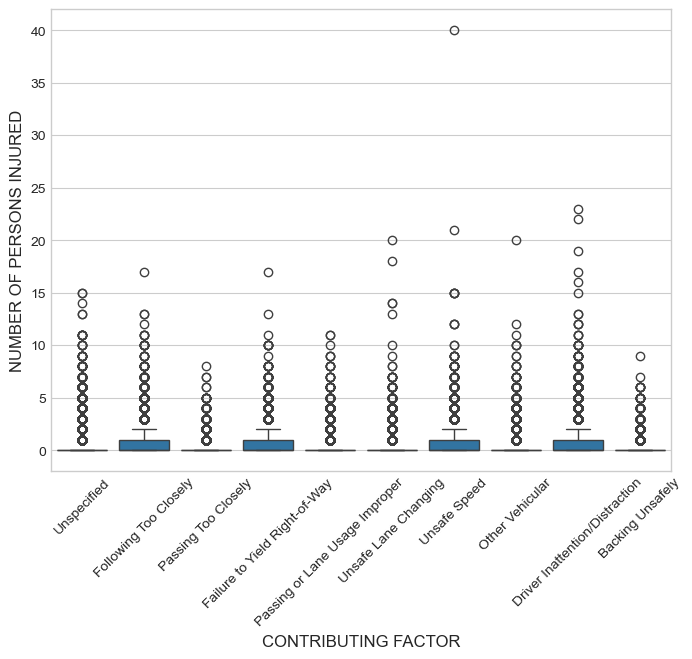

In [61]:
top_factors = df['CONTRIBUTING FACTOR'].value_counts().head(10).index
filtered_factors = df[df['CONTRIBUTING FACTOR'].isin(top_factors)]

plt.figure(figsize=(8,6))
sns.boxplot(data=filtered_factors,  x='CONTRIBUTING FACTOR',
        y='NUMBER OF PERSONS INJURED')

#plt.title("Injury Distribution by Factor")
plt.xlabel("CONTRIBUTING FACTOR")
plt.ylabel("NUMBER OF PERSONS INJURED")
plt.xticks(rotation=45)
plt.savefig("plots/ContributingFactorBoxPlot1.png", dpi=300, bbox_inches='tight')




Based on the provided boxplot, the vast majority of traffic incidents across all contributing factors result in very few injuries, as indicated by the highly compressed interquartile ranges and medians sitting at or near zero. However, the data is heavily right-skewed with numerous extreme outliers, demonstrating that certain driving behaviors have a much higher potential for severe, mass-casualty events. Most notably, "Unsafe Speed" accounts for the single most severe incident recorded (40 injuries), while factors like "Driver Inattention/Distraction," "Unsafe Lane Changing," and "Other Vehicular" frequently produce high-casualty outliers exceeding 15 to 20 injuries. In contrast, factors like "Passing Too Closely" and "Backing Unsafely" maintain a much tighter distribution with significantly lower maximum injury counts, highlighting that speed and high-momentum moving violations carry the greatest risk for widespread harm in a single collision.

## Contribution Share

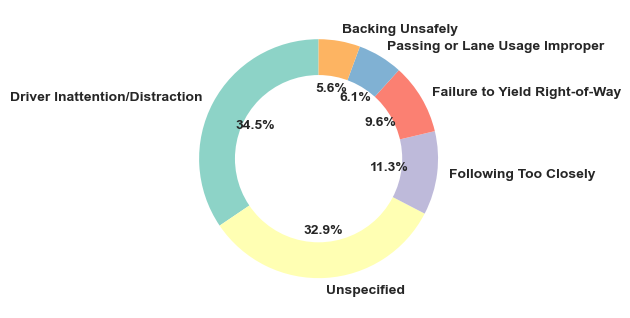

In [62]:
top_factors = df['CONTRIBUTING FACTOR'].value_counts().head(6)

fig, ax = plt.subplots(figsize=(6,6))

# Pie chart
ax.pie(
    top_factors,
    labels=top_factors.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3.colors,
    textprops={'fontsize':10, 'fontweight':'bold'}
)

# Donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

#ax.set_title("Share of Top Contributing Factors")

plt.tight_layout()
fig.savefig("plots/FactorDonut.png", dpi=300, bbox_inches="tight")




Based on the provided donut chart detailing the "Share of Top Contributing Factors," the distribution is heavily dominated by just two primary categories: "Driver Inattention/Distraction" (34.5%) and "Unspecified" (32.9%). Together, these two factors account for more than two-thirds of all incidents represented in this top group, highlighting distracted driving as the leading known cause, while also revealing a significant gap in specific data collection due to the high volume of unspecified records. The remaining specific moving violations make up a much smaller fraction of the total share; "Following Too Closely" (11.3%) and "Failure to Yield Right-of-Way" (9.6%) represent roughly a fifth combined, leaving minor specific infractions like "Passing or Lane Usage Improper" (6.1%) and "Backing Unsafely" (5.6%) as the smallest contributors among the major factors.

### Factor Distribution by Borough

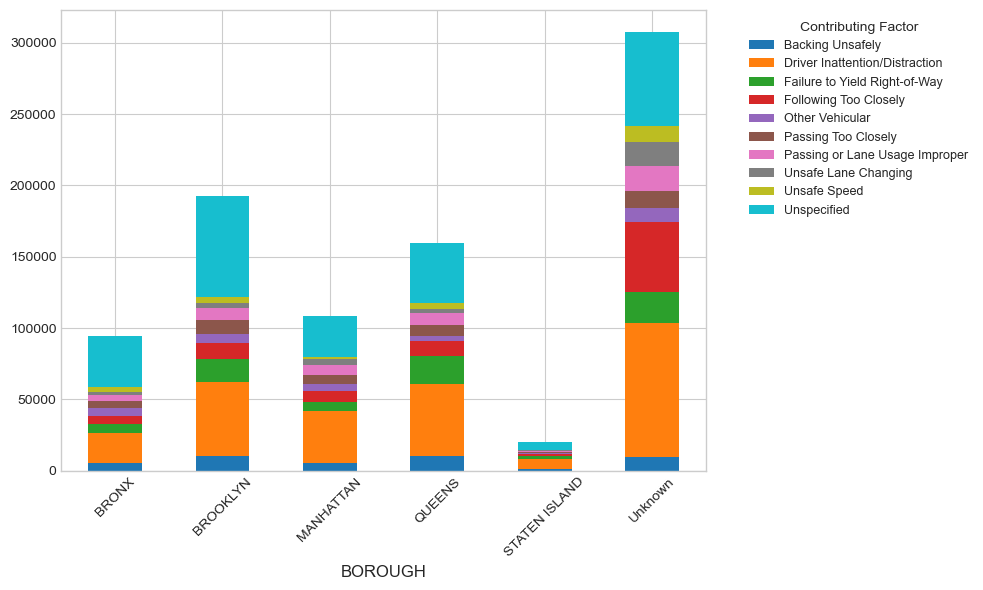

In [63]:
pivot = filtered_factors.pivot_table(
    index='BOROUGH',
    columns='CONTRIBUTING FACTOR',
    values='COLLISION_ID',
    aggfunc='count',
    fill_value=0
)

fig, ax = plt.subplots()
pivot.plot(kind='bar', stacked=True, ax=ax)

#ax.set_title("Top Factors by Borough")
plt.xticks(rotation=45)

# Move legend to the right
ax.legend(
    title="Contributing Factor",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
fig.savefig("plots/TopFactorsByBorough.png", dpi=300, bbox_inches="tight")


The stacked bar chart illustrating "Top Factors by Borough" reveals that Brooklyn and Queens are the primary hotspots for traffic incidents among named boroughs, while a significant volume of data is categorized under an "Unknown" location. Across all regions, "Driver Inattention/Distraction" (orange) and "Unspecified" (light blue) consistently emerge as the most frequent contributing factors, mirroring the trends seen in the overall share data. While Staten Island shows the lowest total incident count, the proportional makeup of factors remains relatively stable across the five boroughs, with "Following Too Closely" and "Failure to Yield Right-of-Way" maintaining their positions as the most common specific moving violations. Interestingly, the "Unknown" category displays a disproportionately high amount of specific violations like "Following Too Closely," suggesting that more detailed reporting often occurs even when the exact geographic borough is not recorded.

### Heatmap Factor vs Vehicle Type

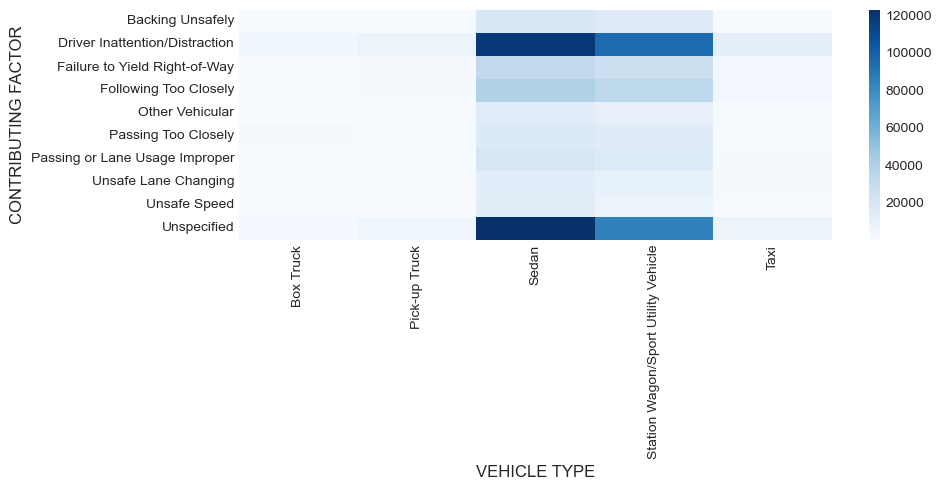

In [64]:
top_factors = df['CONTRIBUTING FACTOR'].value_counts().nlargest(10).index
top_vehicles = df['VEHICLE TYPE'].value_counts().nlargest(5).index

filtered = df[
    df['CONTRIBUTING FACTOR'].isin(top_factors) &
    df['VEHICLE TYPE'].isin(top_vehicles)
]

pivot = filtered.pivot_table(
        index='CONTRIBUTING FACTOR',
        columns='VEHICLE TYPE',
        values='COLLISION_ID',
        aggfunc='count',
        fill_value=0
    )

fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(pivot, cmap='Blues', ax=ax)

#ax.set_title("Crash Frequency by Factor and Vehicle Type")
plt.tight_layout()
fig.savefig("plots/FactorVehicleTypeHeatMap.png", dpi=300, bbox_inches="tight")


Based on the provided heatmap displaying "Crash Frequency by Factor and Vehicle Type," standard passenger vehicles are responsible for the overwhelming majority of recorded incidents. The visual data is heavily anchored by intense dark blue "hotspots" at the intersections of Sedans and Station Wagon/Sport Utility Vehicles with the top contributing factors: "Driver Inattention/Distraction" and "Unspecified." These specific combinations represent the absolute highest crash frequencies in the dataset, easily dwarfing all other categories. In stark contrast, vehicles like Box Trucks, Pick-up Trucks, and Taxis exhibit exceptionally low crash frequencies across the board, appearing almost white on the color scale. While secondary factors like "Following Too Closely" and "Failure to Yield Right-of-Way" show moderate incidence levels, they are again almost exclusively tied to Sedans and SUVs, highlighting that everyday passenger vehicles and distracted driving are the primary drivers of the overall accident volume.

### Boxplot - Injury Distribution by Borough

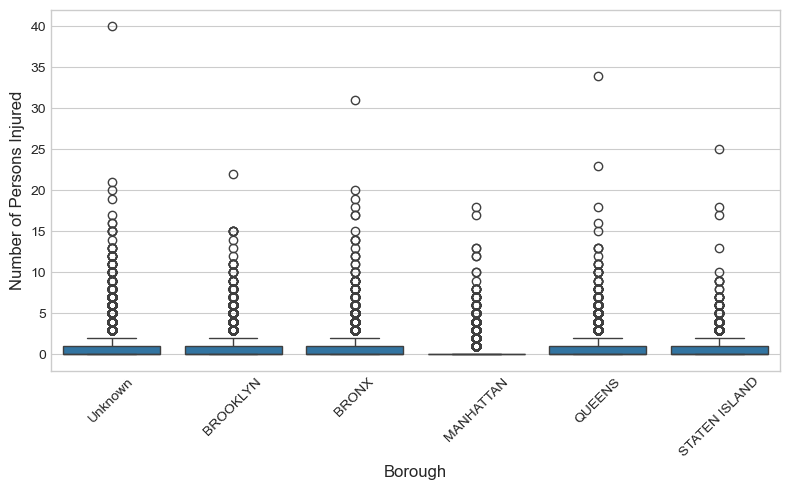

In [65]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='BOROUGH',
    y='NUMBER OF PERSONS INJURED',
    ax=ax
)

#ax.set_title("Injury Distribution by Borough")
ax.set_xlabel("Borough")
ax.set_ylabel("Number of Persons Injured")
ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
fig.savefig("plots/InjuryDistributionbyBorough.png", dpi=300, bbox_inches="tight")

Based on the provided boxplot detailing "Injury Distribution by Borough," the typical traffic incident results in very few injuries across all geographic areas, as shown by the medians and interquartile ranges compressed tightly at or near zero. However, the severity of outlier events varies significantly by location. The "Unknown" location category contains the single most devastating incident recorded (40 injuries) along with a dense cluster of high-casualty events. Among the identified boroughs, Queens and the Bronx experience the most extreme outliers, with single crashes causing upwards of 30 injuries. Conversely, Manhattan stands out with the tightest overall distribution and the lowest maximum injury threshold (peaking below 20). This suggests that while accidents in Manhattan may be frequent, the borough's denser traffic patterns and slower average speeds likely mitigate the risk of the severe, high-impact collisions seen in areas with more open roadways or highways.

### Line chart - Total Injuries by Hour

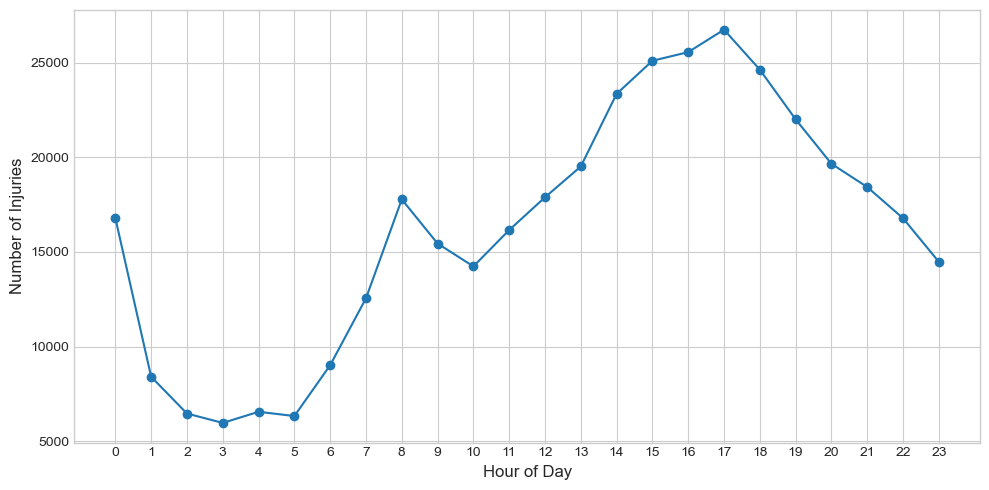

In [66]:
hourly = (
    df.groupby('HOUR')['NUMBER OF PERSONS INJURED']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(hourly['HOUR'], hourly['NUMBER OF PERSONS INJURED'], marker='o')

#ax.set_title("Total Injuries by Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Injuries")
ax.set_xticks(range(0, 24))
ax.grid(True)

fig.tight_layout()
fig.savefig("plots/TotalInjuriesbyHour.png", dpi=300, bbox_inches="tight")

The line chart of "Total Injuries by Hour" demonstrates a clear bimodal distribution that closely tracks typical daily commuting patterns. Injuries reach their absolute lowest point during the early morning hours (3:00 AM to 5:00 AM) before experiencing a sharp rise that peaks around 8:00 AM, coinciding with the morning rush hour. Following a minor mid-morning dip, there is a sustained and significant climb throughout the afternoon, culminating in a daily maximum at 5:00 PM (17:00). This evening peak is notably higher and broader than the morning surge, suggesting that the combination of increased traffic volume, driver fatigue, and diminishing daylight during the evening commute creates the highest-risk window for injuries. After 6:00 PM, injury counts steadily decline as traffic volume tapers off into the night.

### Injury Facet Grid

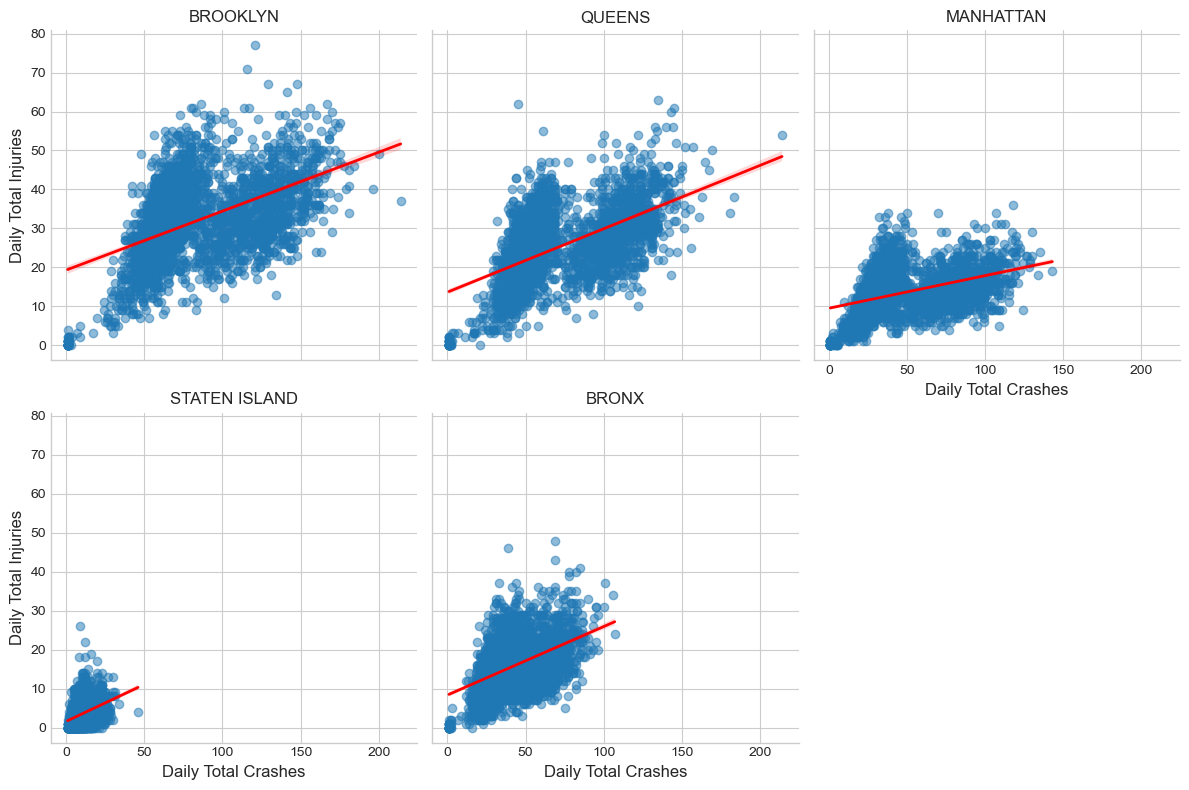

In [78]:
daily_borough_df = df.groupby(['CRASH DATE', 'BOROUGH']).agg(
    Total_Crashes=('COLLISION_ID', 'count'),      # Assuming COLLISION_ID is your unique key
    Total_Injuries=('NUMBER OF PERSONS INJURED', 'sum')
).reset_index()

g = sns.lmplot(
    data=daily_borough_df,
    x="Total_Crashes",
    y="Total_Injuries",
    col="BOROUGH",
    col_wrap=3,
    height=4,
    scatter_kws={'alpha': 0.5, 'color': '#1f77b4'},
    line_kws={'color': 'red', 'linewidth': 2}
)
g.set_axis_labels("Daily Total Crashes", "Daily Total Injuries")
g.set_titles(col_template="{col_name}")

plt.tight_layout()
plt.savefig("plots/Correlated_Facet_Grid.png", dpi=300)
plt.show()

Based on the scatter plot grid comparing "Persons Killed" versus "Persons Injured" across the boroughs, there is no direct correlation between the volume of injuries and the number of fatalities in a single incident; in fact, extreme events tend to be exclusively one or the other. The vast majority of crashes cluster tightly near zero for both metrics. However, looking at the outliers reveals that the events causing the highest number of injuries (such as those approaching 30 to 40 in the Bronx, Queens, and the "Unknown" category) remarkably resulted in zero deaths. Conversely, the single most lethal incident—a stark outlier in Manhattan recording 8 fatalities—involved zero non-fatal injuries. This visual pattern suggests two distinct types of severe accidents: concentrated, catastrophic impacts that are immediately lethal to a small group (such as pedestrians or a single vehicle's occupants), and broader, multi-vehicle or mass-transit collisions that cause widespread but ultimately survivable injuries.

# Logistic regression modelling using scikit-learn

In [68]:
# Reduce categories
top_factors = df["CONTRIBUTING FACTOR"].value_counts().nlargest(10).index
df["CONTRIBUTING FACTOR"] = df["CONTRIBUTING FACTOR"].where(
    df["CONTRIBUTING FACTOR"].isin(top_factors), "Other"
)

df["INJURY_FLAG"] = (df["NUMBER OF PERSONS INJURED"] > 0).astype(int)

top_vehicles = df["VEHICLE TYPE"].value_counts().nlargest(5).index
df["VEHICLE TYPE"] = df["VEHICLE TYPE"].where(
    df["VEHICLE TYPE"].isin(top_vehicles), "Other"
)

# Features
features = ["HOUR", "BOROUGH", "DAY_OF_WEEK", "VEHICLE TYPE", "CONTRIBUTING FACTOR"]

X = df[features]
y = df["INJURY_FLAG"]

# Encode
X = pd.get_dummies(X, drop_first=True)

### Logistic Regression

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

y_pred = model.predict(X)

print("Accuracy:", accuracy_score(y, y_pred))

params = pd.Series(model.coef_[0], index=X.columns)
print(params.sort_values(ascending=False).head(10))

Accuracy: 0.7267586963259662
CONTRIBUTING FACTOR_Failure to Yield Right-of-Way     1.884806
CONTRIBUTING FACTOR_Unsafe Speed                      1.729544
VEHICLE TYPE_Other                                    1.362958
CONTRIBUTING FACTOR_Other                             1.354775
CONTRIBUTING FACTOR_Driver Inattention/Distraction    1.098096
CONTRIBUTING FACTOR_Following Too Closely             1.059364
VEHICLE TYPE_Taxi                                     0.820978
CONTRIBUTING FACTOR_Unspecified                       0.799755
CONTRIBUTING FACTOR_Other Vehicular                   0.767232
VEHICLE TYPE_Sedan                                    0.585686
dtype: float64


The logistic regression model achieved an accuracy of 72.6%, indicating that it can reasonably predict whether a crash will result in injury. The most significant predictors were contributing factors such as failure to yield right-of-way, driver distraction, and following too closely. These variables had the highest positive coefficients, indicating a strong association with injury occurrence. In contrast, variables like borough and day of the week had relatively small effects. This suggests that driver behavior plays a more critical role in injury outcomes than location or time.

### Plotting Top Coefficients

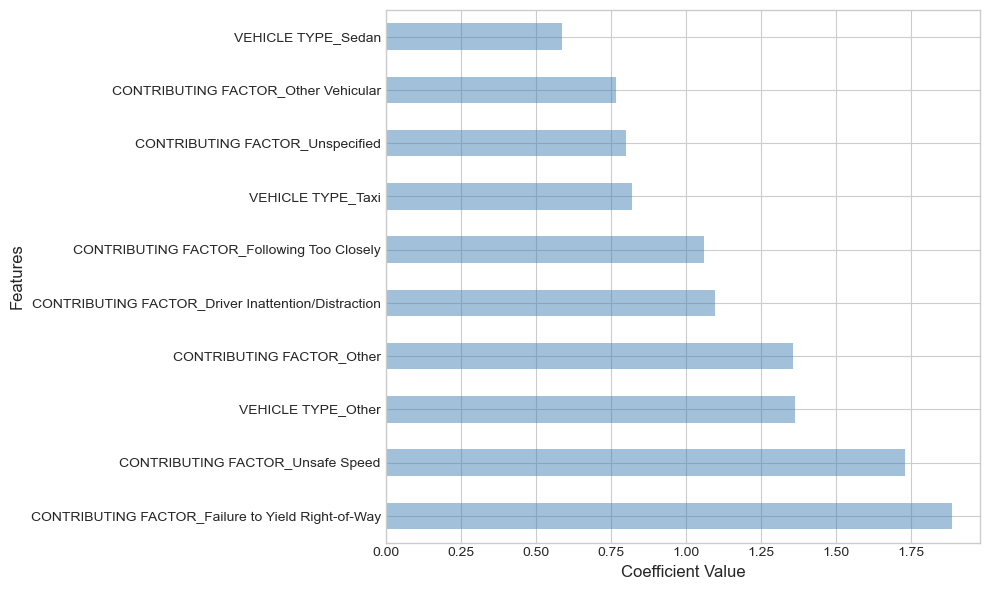

In [70]:
top_features = params.sort_values(ascending=False).head(10)

plt.figure()
top_features.plot(kind='barh',alpha=0.5, color='steelblue')
#plt.title("Top Factors Increasing Injury Probability")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("plots/TopCoefficients.png", dpi=300, bbox_inches="tight")

Based on the horizontal bar chart displaying model coefficients, "Failure to Yield Right-of-Way" stands out as the strongest predictor for increasing the probability of an injury, possessing a coefficient value nearly double that of several other major infractions. While earlier frequency charts indicated that "Driver Inattention/Distraction" caused the highest raw volume of accidents, this predictive model suggests that "Failure to Yield" is significantly more likely to actually result in physical harm when a crash does occur. Common moving violations like "Driver Inattention/Distraction" and "Following Too Closely" still prominently raise the likelihood of injury, but to a lesser degree. Notably, spatial and temporal features—such as the incident occurring in Brooklyn or on a Sunday—have a positive, yet extremely marginal, influence on injury probability when compared to the severe impact of direct, behavioral driving errors.

### Predicted Probability of Injury

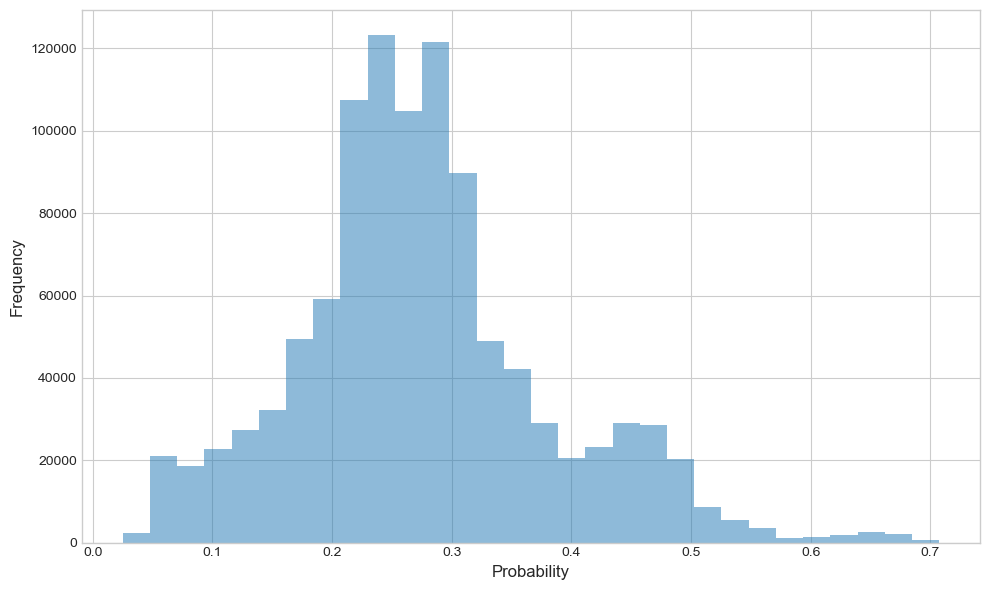

In [71]:
# Get probabilities
y_prob = model.predict_proba(X)[:, 1]

plt.figure()
plt.hist(y_prob, bins=30, alpha = 0.5)
#plt.title("Predicted Probability of Injury")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("plots/PredictedProbability.png", dpi=300, bbox_inches="tight")

The distribution is unimodal and slightly right-skewed, with the vast majority of predicted probabilities concentrated between 0.20 and 0.35. This indicates that for most traffic incidents in this dataset, the model estimates a 20% to 35% chance of an injury occurring. While there is a secondary "hump" or shoulder around the 0.45 mark, very few incidents are assigned a high-certainty probability (above 0.60). This suggests that while certain factors (like "Failure to Yield") significantly increase risk, the presence of an injury in a collision is still subject to a high degree of randomness or depends on variables not fully captured by the current feature set.

## Linear Regression  

In [72]:
from sklearn.linear_model import LinearRegression

# Creating model
model_lr = LinearRegression()

# Trainning model
model_lr.fit(X, y)

# Predictions
y_pred_lr = model_lr.predict(X)

from sklearn.metrics import r2_score, mean_squared_error

# R² Score
r2 = r2_score(y, y_pred_lr)

# MSE
mse = mean_squared_error(y, y_pred_lr)

print("R² Score:", r2)
print("Mean Squared Error:", mse)

print("Linear Regression model built successfully")

R² Score: 0.05577311352597425
Mean Squared Error: 0.1885182142405863
Linear Regression model built successfully


Linear regression was implemented to examine the relationship between crash-related variables and injury outcomes. The model achieved a low R² score of 0.056, indicating limited explanatory power. This is expected because the target variable is binary, and linear regression is not designed for classification tasks.

While linear regression is not suitable for predicting injury outcomes, it serves as a baseline model to understand general relationships in the data. More appropriate models for this problem include logistic regression and decision trees, which are specifically designed for classification tasks. Therefore, the next one is decision Tree. 

### Decision Tree

In [73]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create model
model_dt = DecisionTreeClassifier(max_depth=5)

# Train
model_dt.fit(X, y)

# Predict
y_pred_dt = model_dt.predict(X)

# Accuracy
accuracy = accuracy_score(y, y_pred_dt)

print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.7292525570416994


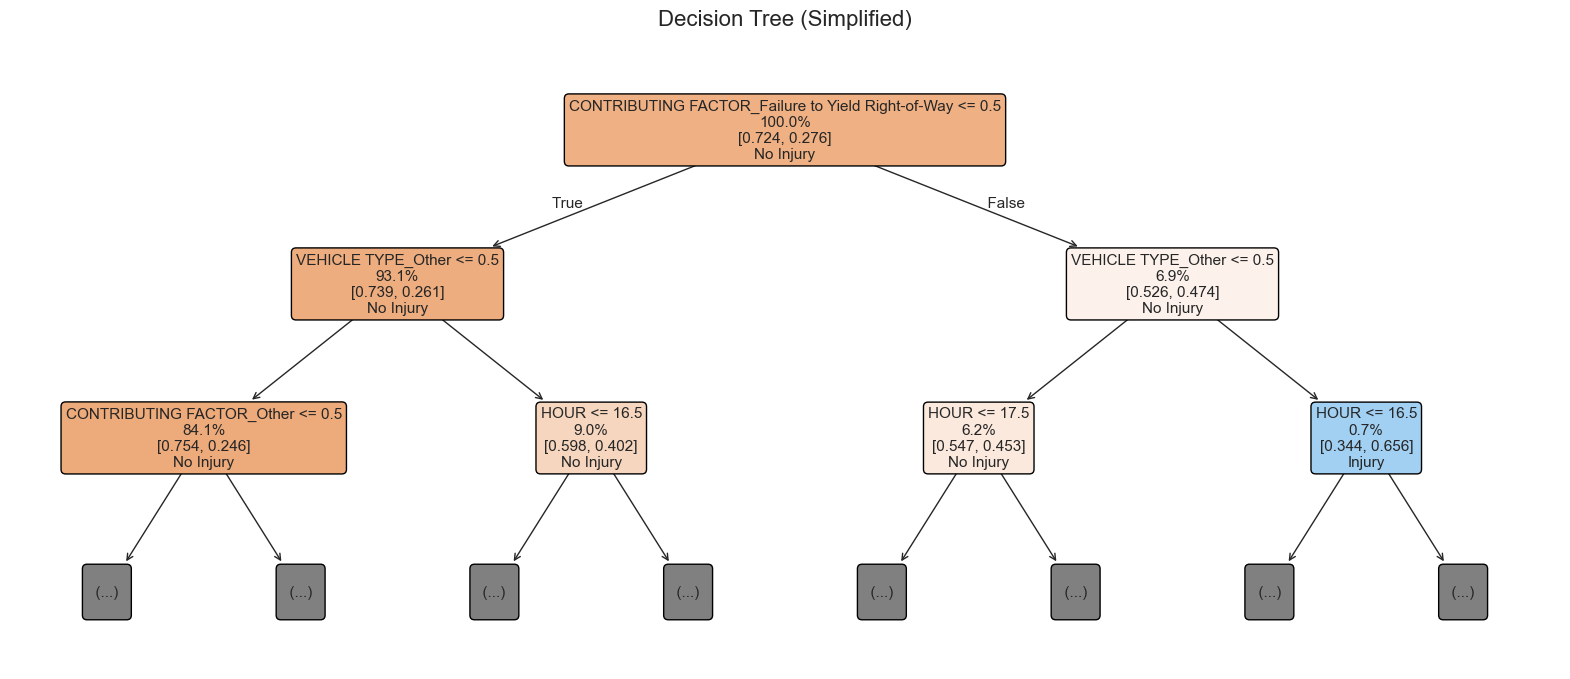

In [74]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))

plot_tree(
    model_dt,
    feature_names=X.columns,
    class_names=["No Injury", "Injury"],
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=11,
    proportion=True,
    impurity=False,   
    label='none')
plt.title("Decision Tree (Simplified)", fontsize=16, pad=20)
plt.savefig("plots/DecisionTree_minimal.png", dpi=150, bbox_inches="tight")
plt.show()

The decision tree model shows that failure to yield right-of-way is the most important factor influencing whether a crash results in injury, as it appears as the first split in the tree. At the root node, about 27.6% of crashes result in injury, highlighting the overall injury rate in the dataset.

After this split, the model further considers vehicle type and crash hour. For example, in some branches, injury probability increases to over 65%, indicating that certain combinations of factors significantly raise the risk of injury. This shows that crash outcomes are influenced by multiple factors working together rather than individually.

Overall, the decision tree achieved an accuracy of about 72.9%, indicating good predictive performance. 

### Heat Map 

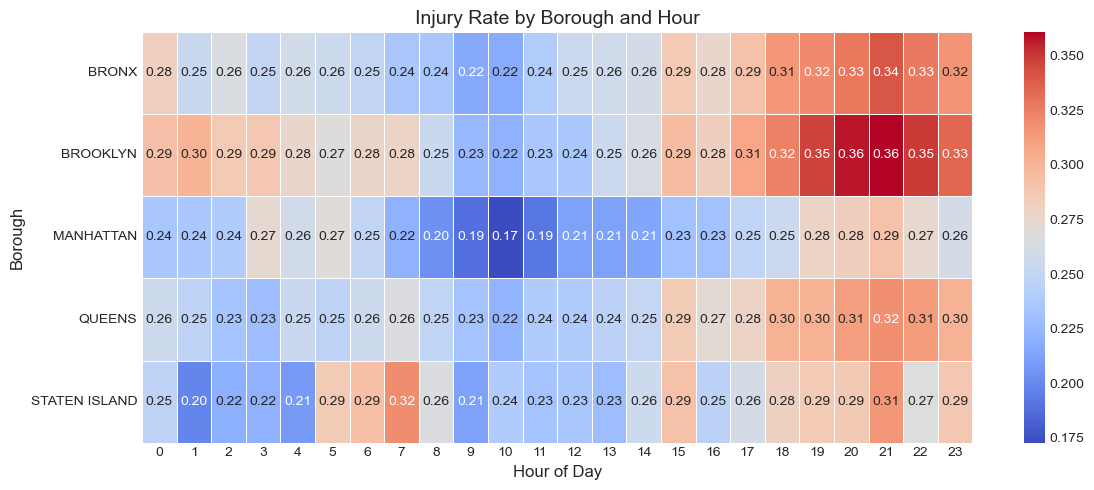

In [75]:
df = df[df["BOROUGH"] != "Unknown"]
rate_heatmap = df.pivot_table(
    index="BOROUGH",
    columns="HOUR",
    values="INJURY_FLAG",
    aggfunc="mean"
)

plt.figure(figsize=(12,5))
sns.heatmap(
    rate_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Injury Rate by Borough and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Borough")
plt.tight_layout()
plt.savefig("plots/InjuryRateHeatmap.png", dpi=150, bbox_inches="tight")
plt.show()

This heatmap shows how injury rates change across different boroughs and times of the day, and there are some clear patterns. Injury rates generally increase in the late afternoon and evening, especially between 5 PM and 9 PM, which likely matches peak traffic hours. Brooklyn stands out with the highest injury rates, reaching around 36%, followed by the Bronx and Queens, while Manhattan tends to have lower rates throughout the day.

Staten Island shows more stable and slightly lower injury rates compared to other boroughs. Overall, this visualization shows that both the location and time of day affect how serious crashes are, not just how often they happen.